<h1> Geometric Operations and Other Mathematical Tools</h1>


Estimated time needed: **40** minutes


<h2>Objectives</h2>


In the first part of the lab, you will apply geometric transformations to an image. This allows you to perform different operations like reshape translation, i.e. to shift, reshape and rotate the image. In the second part of the lab, you will learn how to apply some basic array and matrix operations to the image. 


<ul>
    <li><a href='#PT'> Geometric Operations  </a>
        <ul>
            <li>Scaling</li>
            <li>Translation</li>
            <li>Rotation</li>   
          </ul>
        <li><a href='#PT'>  Mathematical Operations   </a>
        <ul>
            <li>Array Operations  </li>
            <li>Matix Operations n</li> 
          </ul>


</ul>


----


Download the image for the lab:


In [2]:
import urllib.request  
# Import module urllib.request dùng để gửi request HTTP (tải dữ liệu từ Internet)

urls = [
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/lenna.png",
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/baboon.png",
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/barbara.png"
]
# Danh sách các URL chứa đường dẫn đến các file ảnh cần tải

names = ["lenna.png", "baboon.png", "barbara.png"]
# Danh sách tên file tương ứng để lưu ảnh sau khi tải về

for url, name in zip(urls, names):
    # zip() ghép từng URL với từng tên file theo cặp
    # Ví dụ: (urls[0], names[0]), (urls[1], names[1]), ...

    urllib.request.urlretrieve(url, name)
    # Gửi request tới URL để tải dữ liệu
    # Sau đó lưu dữ liệu đó thành file với tên 'name' trên máy

print("Downloaded!")
# In thông báo khi tất cả các file đã được tải xong

Downloaded!


We will be using the following imported functions in this lab:


In [1]:
import matplotlib.pyplot as plt  
# Import thư viện matplotlib, cụ thể là module pyplot
# pyplot dùng để vẽ biểu đồ, hiển thị hình ảnh (imshow), đồ thị, histogram,...

from PIL import Image  
# Import lớp Image từ thư viện Pillow (PIL)
# Pillow dùng để mở, đọc, xử lý ảnh (PNG, JPG, BMP,...)
# Image.open() sẽ load ảnh từ file thành đối tượng ảnh trong Python

import numpy as np  
# Import thư viện NumPy – nền tảng cho xử lý số và mảng trong Python
# NumPy dùng để lưu ảnh dưới dạng mảng (array), xử lý pixel, toán học, ML

First, let's define a helper function to plot two images side-by-side. You will not need to understand this code this moment, but this function will be used repeatedly in this tutorial to showcase the results. 


In [2]:
def plot_image(image_1, image_2, title_1="Orignal", title_2="New Image"):
    # Định nghĩa hàm plot_image
    # image_1, image_2: hai ảnh đầu vào (dạng mảng NumPy hoặc ảnh PIL)
    # title_1, title_2: tiêu đề cho từng ảnh (có giá trị mặc định)

    plt.figure(figsize=(10, 10))
    # Tạo một figure (khung vẽ) mới
    # figsize=(10,10) xác định kích thước figure (rộng 10 inch, cao 10 inch)

    plt.subplot(1, 2, 1)
    # Chia figure thành lưới 1 hàng, 2 cột
    # Chọn ô thứ 1 để vẽ (ảnh bên trái)

    plt.imshow(image_1, cmap="gray")
    # Hiển thị ảnh thứ nhất
    # cmap="gray" ép hiển thị ảnh theo thang xám (grayscale)

    plt.title(title_1) # Gán tiêu đề cho ảnh thứ nhất

    plt.subplot(1, 2, 2) # Chọn ô thứ 2 trong lưới (ảnh bên phải)

    plt.imshow(image_2, cmap="gray") # Hiển thị ảnh thứ hai với thang xám

    plt.title(title_2) # Gán tiêu đề cho ảnh thứ hai

    plt.show() # Hiển thị toàn bộ figure lên màn hình

#  Geometric Transformations


 Geometric transformations allow you to perform different operations like translation, i.e. to shift, reshape and rotate the image.


We can resize an image using the method  <code>resize()</code> of <code>PIL</code> images, which takes the resized image's <code>width</code> and <code>height</code> as paramters. 

Consider the following image:


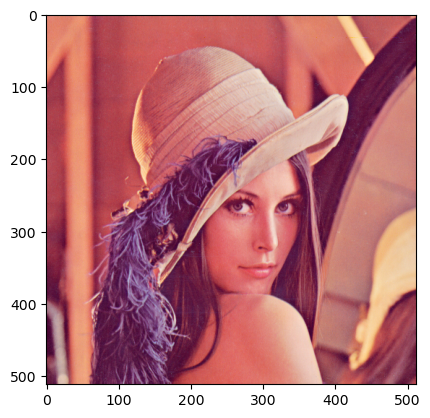

In [3]:
image = Image.open("lenna.png")
# Mở file ảnh "lenna.png" từ thư mục hiện tại
# Image.open() không load ảnh thành mảng NumPy ngay mà tạo ra một đối tượng ảnh của PIL (PIL.Image.Image)

plt.imshow(image)
# Hiển thị ảnh lên figure bằng matplotlib
# matplotlib tự động hiểu đối tượng PIL và render ảnh
# Nếu ảnh là RGB → hiển thị màu
# Nếu ảnh là grayscale → hiển thị thang xám

plt.show() # Hiển thị ảnh ra màn hình

We can scale the horizontal axis by two and leave the vertical axis as is:


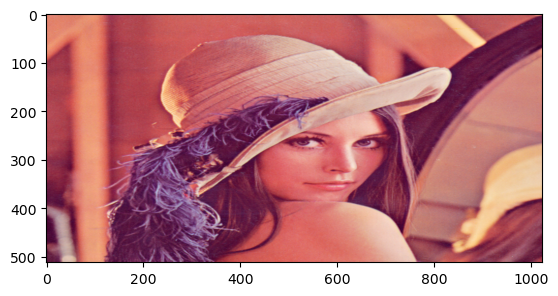

In [4]:
width, height = image.size
# image.size trả về một tuple (width, height)
# width  : chiều rộng của ảnh (số pixel theo trục ngang)
# height : chiều cao của ảnh (số pixel theo trục dọc)

new_width = 2 * width
# Tăng chiều rộng ảnh lên gấp đôi so với ảnh ban đầu

new_hight = height
# Giữ nguyên chiều cao ảnh (Lưu ý: biến new_hight đang bị viết sai chính tả, đúng ra nên là new_height)

new_image = image.resize((new_width, new_hight))
# Resize ảnh sang kích thước mới
# resize() nhận vào tuple (width, height)
# PIL sẽ nội suy lại pixel để phù hợp kích thước mới

plt.imshow(new_image) # Hiển thị ảnh sau khi resize

plt.show() # Render ảnh ra màn hình

In the same manner, we can scale the vertical axis by two:


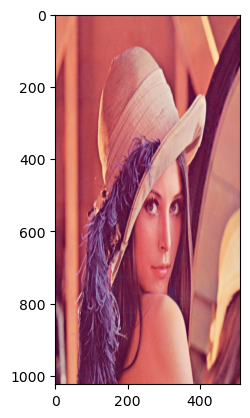

In [5]:
new_width = width # Giữ nguyên chiều rộng của ảnh so với ảnh ban đầu

new_hight = 2 * height
# Tăng chiều cao ảnh lên gấp đôi
# Ảnh sẽ bị kéo dãn theo chiều dọc

new_image = image.resize((new_width, new_hight))
# Resize ảnh với kích thước mới (width, height)
# PIL sẽ nội suy lại các pixel để tạo ảnh mới
# Do chỉ tăng chiều cao → ảnh bị méo theo trục dọc

plt.imshow(new_image) # Hiển thị ảnh sau khi resize

plt.show() # Render ảnh ra màn hình

We can double both the width and the height of the image:


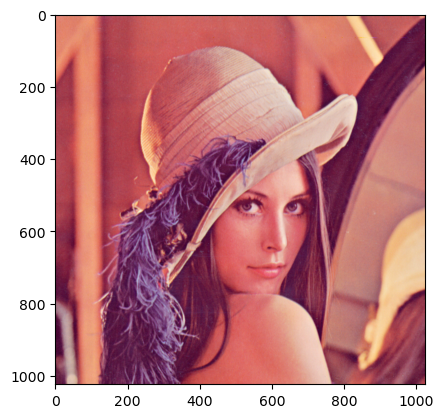

In [6]:
new_width = 2 * width # Tăng chiều rộng ảnh lên gấp 2 lần so với ảnh ban đầu

new_hight = 2 * height
# Tăng chiều cao ảnh lên gấp 2 lần so với ảnh ban đầu
# Ảnh được phóng to đều theo cả chiều ngang và chiều dọc

new_image = image.resize((new_width, new_hight))
# Resize ảnh sang kích thước mới (width, height)
# PIL sẽ tạo thêm pixel mới bằng nội suy (interpolation)
# Do phóng to đều 2 chiều → ảnh không bị méo hình, chỉ giảm độ sắc nét

plt.imshow(new_image) # Hiển thị ảnh đã được phóng to

plt.show() # Render ảnh ra màn hình

We can also shrink the image's width and height both by 1/2:


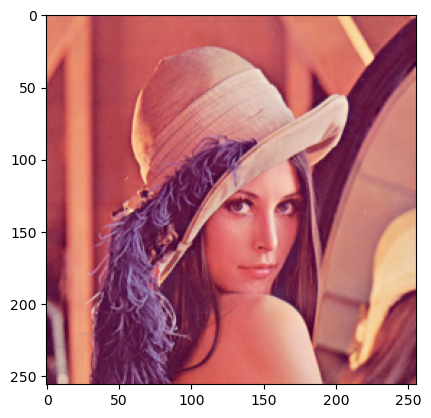

In [7]:
new_width = width // 2
# Chia đôi chiều rộng ảnh
# Toán tử // là phép chia lấy phần nguyên
# Đảm bảo kích thước ảnh sau resize là số nguyên (bắt buộc trong PIL)

new_hight = height // 2
# Chia đôi chiều cao ảnh
# Ảnh sẽ được thu nhỏ đều theo cả hai chiều

new_image = image.resize((new_width, new_hight))
# Resize ảnh sang kích thước mới (width, height)
# PIL sẽ loại bỏ bớt thông tin pixel và nội suy lại
# Do thu nhỏ đều → ảnh không bị méo hình

plt.imshow(new_image) # Hiển thị ảnh sau khi thu nhỏ

plt.show() # Render ảnh ra màn hình

## Rotation 


We can rotate an image by angle $\theta$, using the method `rotate`.


We can rotate our toy image by 45 degrees:


In [8]:
theta = 45
# Góc quay ảnh (đơn vị: độ)
# Giá trị dương → quay ngược chiều kim đồng hồ (counter-clockwise)

new_image = image.rotate(theta)
# Quay ảnh một góc theta quanh tâm ảnh
# PIL mặc định:
# - Quay ngược chiều kim đồng hồ
# - Không tự mở rộng kích thước ảnh (expand=False)
# - Phần ảnh vượt ra ngoài khung sẽ bị cắt
# - Các pixel mới được tạo bằng nội suy

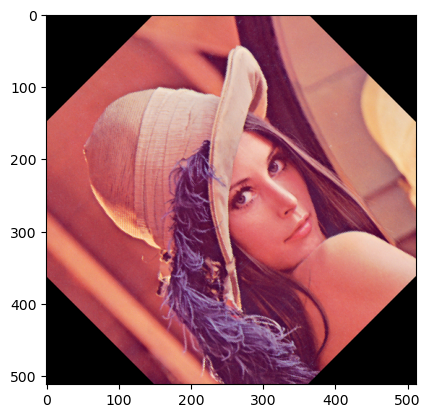

In [9]:
plt.imshow(new_image)
# Hiển thị ảnh new_image lên figure của matplotlib
# matplotlib tự động:
# - Nhận diện ảnh PIL hoặc mảng NumPy
# - Ánh xạ giá trị pixel thành màu sắc
# - Nếu ảnh grayscale mà không chỉ định cmap → có thể hiển thị sai màu

plt.show() # Render (vẽ) toàn bộ figure ra màn hình

# Mathematical Operations 


## Array Operations 


We can perform array operations on an image; Using Python broadcasting, we can add a constant to each pixel's intensity value. 

Before doing that, we must first we convert the PIL image to a numpy array.


In [10]:
image = np.array(image)
# Chuyển đối tượng ảnh PIL (PIL.Image.Image) sang mảng NumPy
# Sau khi chuyển:
# - Ảnh grayscale → mảng 2 chiều (height, width)
# - Ảnh màu RGB → mảng 3 chiều (height, width, 3)
# Mỗi phần tử trong mảng là giá trị pixel (thường từ 0 đến 255)

We can then add the constant to the image array:


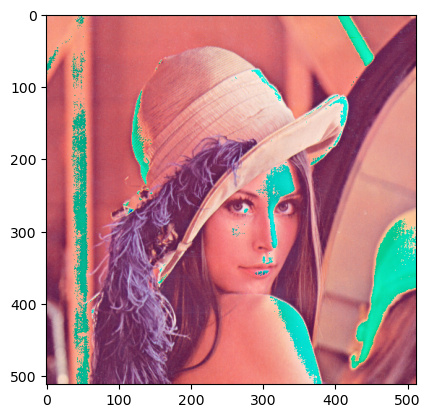

In [11]:
new_image = image + 20
# Cộng giá trị 20 vào tất cả các pixel của ảnh
# Vì image là mảng NumPy → phép cộng được áp dụng cho TỪNG pixel (vectorized operation)
# Làm ảnh sáng hơn
# Lưu ý: pixel thường nằm trong khoảng [0, 255]
# Nếu vượt quá 255 → có thể bị tràn giá trị (overflow) hoặc hiển thị sai

plt.imshow(new_image)
# Hiển thị ảnh sau khi tăng độ sáng
# matplotlib sẽ hiển thị trực tiếp mảng NumPy

plt.show() # Render ảnh ra màn hình

We can also multiply every pixel's intensity value by a constant value.


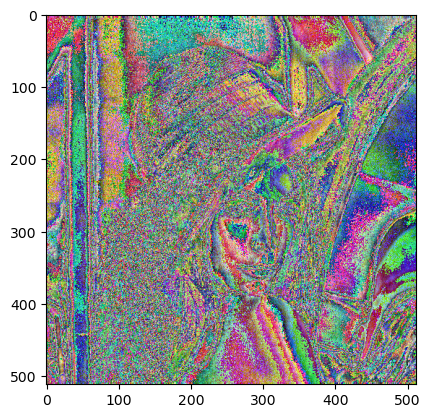

In [12]:
new_image = 10 * image
# Nhân tất cả các pixel của ảnh với 10
# Đây là phép nhân theo phần tử (element-wise) của NumPy
# Làm ảnh sáng lên RẤT MẠNH và tăng tương phản

plt.imshow(new_image)
# Hiển thị ảnh sau khi nhân pixel
# matplotlib sẽ cố hiển thị nhưng có thể cho kết quả sai nếu bị tràn giá trị

plt.show() # Render ảnh ra màn hình

We can add the elements of two arrays of equal shape. In this example, we generate an array of random noises with the same shape and data type as our image.


In [13]:
Noise = np.random.normal(0, 20, (height, width, 3)).astype(np.uint8)
# Tạo một mảng nhiễu ngẫu nhiên theo phân phối chuẩn (Gaussian)
# 0      : giá trị trung bình (mean) của nhiễu → nhiễu xoay quanh 0
# 20     : độ lệch chuẩn (standard deviation) → mức độ mạnh/yếu của nhiễu
# (height, width, 3) : kích thước nhiễu
#   - height, width: khớp với kích thước ảnh
#   - 3: số kênh màu (RGB)
# astype(np.uint8):
#   - Chuyển kiểu dữ liệu sang uint8 (0–255)
#   - Phù hợp để cộng trực tiếp vào ảnh màu

Noise.shape
# Trả về kích thước của mảng Noise
# Kết quả sẽ là (height, width, 3)

(512, 512, 3)

We add the generated noise to the image and plot the result. We see the values that have corrupted the image:


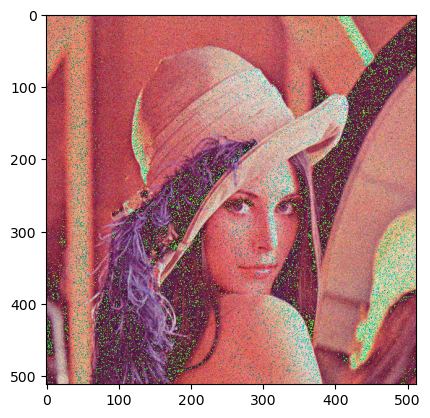

In [14]:
new_image = image + Noise
# Cộng ma trận nhiễu Noise vào ảnh gốc image
# Phép cộng được thực hiện cho TỪNG pixel và TỪNG kênh màu (R, G, B)
# image và Noise phải có cùng kích thước (height, width, 3)
# Kết quả là ảnh bị nhiễu (noisy image)

plt.imshow(new_image)
# Hiển thị ảnh sau khi thêm nhiễu
# Nếu không giới hạn giá trị pixel, ảnh có thể bị loang màu do tràn số

plt.show() # Render ảnh ra màn hình

At the same time, we can multiply the elements of two arrays of equal shape. We can multiply the random image and the Lenna image and plot the result. 


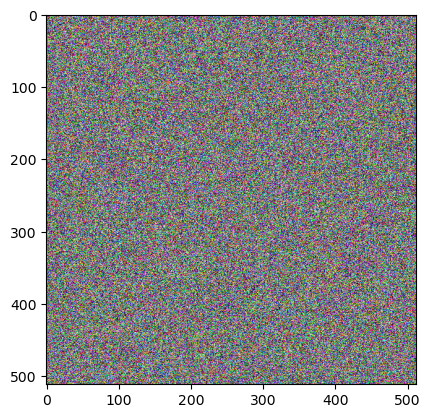

In [15]:
new_image = image * Noise
# Nhân từng pixel của ảnh với giá trị nhiễu tương ứng
# Đây là phép nhân theo phần tử (element-wise) của NumPy
# image và Noise phải có cùng kích thước (height, width, 3)
# Kiểu nhiễu này gọi là nhiễu nhân (multiplicative noise)
# Thường dùng để mô phỏng nhiễu ánh sáng, nhiễu speckle

plt.imshow(new_image)
# Hiển thị ảnh sau khi nhân với nhiễu
# Nếu không chuẩn hóa và giới hạn giá trị pixel → ảnh dễ bị sai màu, cháy sáng

plt.show()
# Render ảnh ra màn hình

## Matrix Operations 


Grayscale images are matrices. Consider the following grayscale image:


In [17]:
im_gray = Image.open("barbara.png")
# Mở file ảnh "barbara.png" từ thư mục hiện tại
# Image.open() đọc dữ liệu ảnh từ ổ đĩa
# Kết quả trả về là một đối tượng PIL.Image.Image
# Lúc này ảnh CHƯA phải là mảng NumPy

Even though the image is gray, it has three channels; we can convert it to a one-channel image.


In [18]:
from PIL import ImageOps
# Import module ImageOps từ thư viện Pillow (PIL)
# ImageOps cung cấp các phép xử lý ảnh mức cao (image operations)
# Chủ yếu dùng cho:
# - Chuyển ảnh sang âm bản (invert)
# - Chuyển grayscale
# - Tự động cân bằng sáng (autocontrast)
# - Lật ảnh (flip, mirror)
# - Cắt ảnh theo mask

In [19]:
im_gray = ImageOps.grayscale(im_gray)
# Chuyển ảnh im_gray sang ảnh xám (grayscale)
# Hàm grayscale() của ImageOps:
# - Nhận vào ảnh PIL (RGB hoặc RGBA)
# - Chuyển thành ảnh 1 kênh (mode = "L")
# - Mỗi pixel có giá trị từ 0 (đen) đến 255 (trắng)

We can convert the PIL image to a numpy array:


In [20]:
im_gray = np.array(im_gray)
# Chuyển ảnh grayscale (PIL Image, mode "L") sang mảng NumPy
# Sau khi chuyển:
# - im_gray là mảng NumPy 2 chiều
# - Shape: (height, width)
# - Mỗi phần tử là giá trị pixel xám trong khoảng [0, 255]
# - Kiểu dữ liệu thường là uint8

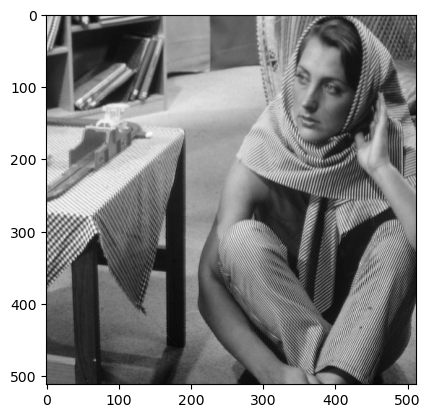

In [21]:
plt.imshow(im_gray, cmap='gray')
# Hiển thị ảnh grayscale (mảng NumPy 2 chiều)
# cmap='gray' chỉ định bảng màu thang xám
# Giá trị pixel:
#   0   → màu đen
#   255 → màu trắng
# Nếu không chỉ định cmap, matplotlib có thể hiển thị sai màu (giả màu)

plt.show() # Render ảnh ra màn hình

We can apply algorithms designed for matrices.  We can use  Singular Value Decomposition, decomposing our image matrix into  a product of three matrices.


In [22]:
U, s, V = np.linalg.svd(im_gray, full_matrices=True)
# Thực hiện Singular Value Decomposition (SVD) trên ảnh grayscale
# im_gray: mảng NumPy 2 chiều (height, width)

# Kết quả phân rã:
# im_gray = U @ diag(s) @ V

# U: ma trận trực giao (height x height)
#    - Các cột của U là các vector riêng trái
#    - Biểu diễn cấu trúc theo chiều dọc của ảnh

# s: vector 1 chiều chứa các singular values (độ dài = min(height, width))
#    - Giá trị sắp xếp giảm dần
#    - Giá trị càng lớn → đóng góp càng nhiều vào ảnh gốc

# V: ma trận trực giao (width x width)
#    - Các hàng của V là các vector riêng phải
#    - Biểu diễn cấu trúc theo chiều ngang của ảnh

# full_matrices=True:
# - U có kích thước (H x H)
# - V có kích thước (W x W)
# - Đầy đủ ma trận, tốn bộ nhớ hơn

We see <code>s</code> is not rectangular:


In [23]:
s.shape
# Trả về kích thước (shape) của vector s
# s là vector 1 chiều chứa các singular values của ảnh
# Shape có dạng: (min(height, width),)

(512,)

We can convert  <code>s</code> to a diagonal matrix <code>S</code>:


In [24]:
S = np.zeros((im_gray.shape[0], im_gray.shape[1]))
# Tạo một ma trận S toàn số 0
# Kích thước S = (height, width) của ảnh grayscale
# Ma trận này sẽ dùng để chứa các singular values trên đường chéo chính

S[:image.shape[0], :image.shape[0]] = np.diag(s)
# np.diag(s) tạo ma trận đường chéo từ vector s
#   - Các phần tử của s nằm trên đường chéo chính
#   - Các phần tử khác = 0
#
# Gán ma trận đường chéo này vào góc trên bên trái của S
# [:image.shape[0], :image.shape[0]]:
#   - Lấy khối vuông kích thước (min(H, W) x min(H, W))
#   - Đảm bảo kích thước phù hợp để đặt diag(s)

We can plot the matrix U and V:


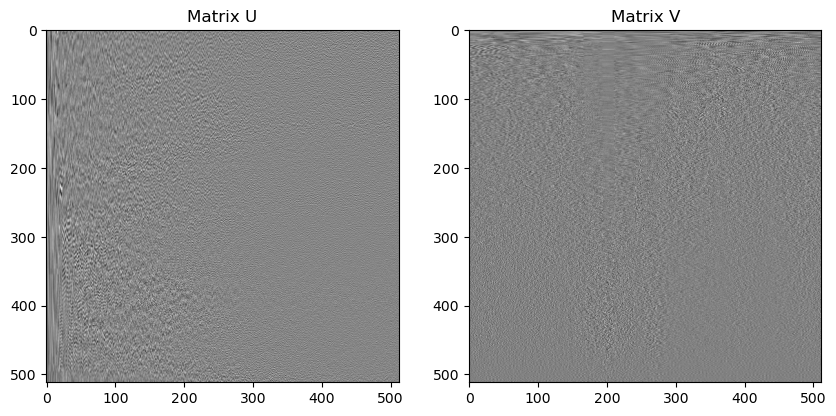

In [26]:
plot_image(U, V, title_1="Matrix U", title_2="Matrix V")
# Hiển thị ma trận U và V như hai ảnh xám để quan sát trực quan
# U: ma trận trực giao (height x height)
#    - Mỗi cột biểu diễn một vector cơ sở theo chiều dọc của ảnh
#
# V: ma trận trực giao (width x width)
#    - Mỗi hàng biểu diễn một vector cơ sở theo chiều ngang của ảnh
#
# plot_image():
# - Dùng plt.imshow() với cmap='gray'
# - Ánh xạ giá trị trong ma trận => mức xám để dễ quan sát

We see most of the elements in S are zero:


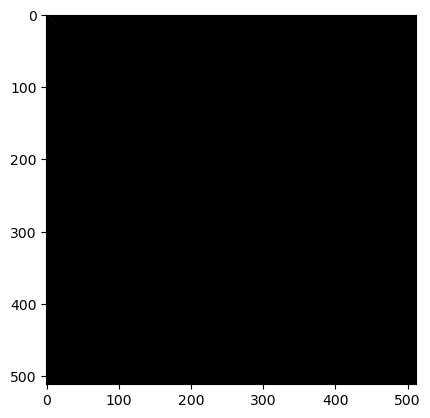

In [27]:
plt.imshow(S, cmap='gray')  
# Hiển thị ma trận S dưới dạng ảnh
# - S là ma trận chứa các giá trị singular values (đường chéo)
# - cmap='gray' dùng thang màu xám vì S là ma trận 2D (ảnh xám)

plt.show() # Hiển thị ảnh ra màn hình

We can find the matrix product of all the  matrices. First, we can perform matrix multiplication on S and U and assign it to `B` and plot the results: 


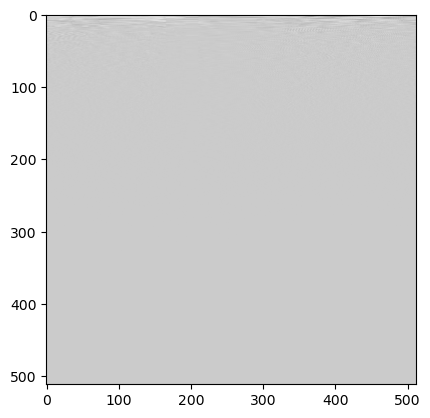

In [28]:
B = S.dot(V)
# Nhân ma trận S với V (S · V)
# - S: ma trận singular values (chứa độ quan trọng của các thành phần ảnh)
# - V: ma trận chứa các vector cơ sở bên phải (right singular vectors)
# Kết quả B là bước trung gian trong quá trình khôi phục ảnh từ SVD

plt.imshow(B, cmap='gray')
# Hiển thị ma trận B dưới dạng ảnh xám
# Vì B là ma trận 2 chiều nên dùng cmap='gray'

plt.show() # Hiển thị ảnh ra màn hình

We can find the matrix product of `U`, `S`, and `B`. We see it's the entire image:


In [29]:
A = U.dot(B)
# Nhân ma trận U với ma trận B
# - U: ma trận chứa các vector cơ sở bên trái (left singular vectors)
# - B = S · V (đã tính ở bước trước)
# => A = U · S · V
# Đây là công thức khôi phục lại ảnh ban đầu từ SVD

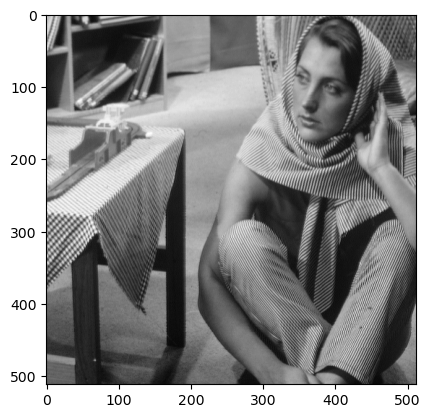

In [30]:
plt.imshow(A, cmap='gray')
# Hiển thị ma trận A dưới dạng ảnh xám
# A là ảnh đã được tái tạo lại từ SVD theo công thức A = U · S · V

plt.show() # Render và hiển thị ảnh ra màn hình

It turns out that many elements are redundant. We can eliminate some rows and columns of S and V and approximate the image by finding the product:


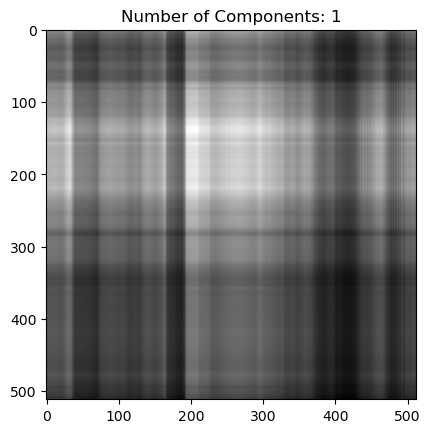

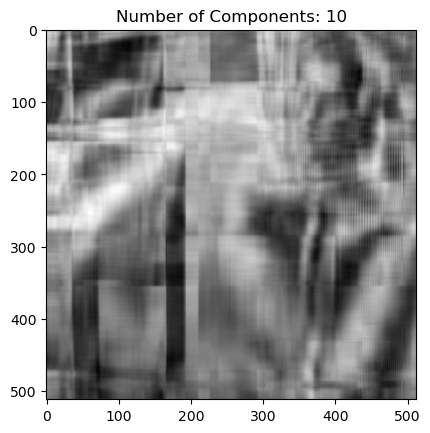

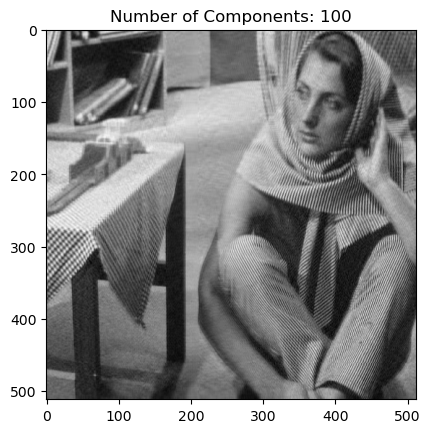

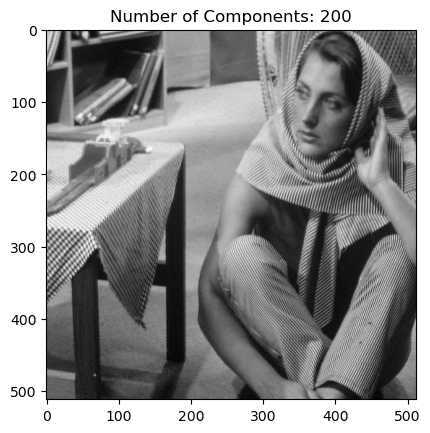

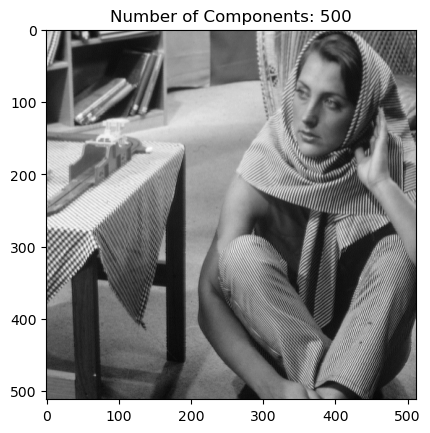

In [31]:
for n_component in [1, 10, 100, 200, 500]:
    # Duyệt qua các số lượng singular values (thành phần chính) khác nhau
    # n_component càng lớn → ảnh càng rõ, nhưng dung lượng càng tăng

    S_new = S[:, :n_component]
    # Lấy n_component cột đầu tiên của ma trận S
    # Tương ứng với việc chỉ giữ lại n_component singular values lớn nhất

    V_new = V[:n_component, :]
    # Lấy n_component hàng đầu tiên của ma trận V
    # Phù hợp kích thước để nhân với S_new

    A = U.dot(S_new.dot(V_new))
    # Tái tạo ảnh xấp xỉ từ SVD rút gọn
    # Công thức: A ≈ U · S_new · V_new
    # Đây là ảnh đã được nén

    plt.imshow(A, cmap='gray') # Hiển thị ảnh tái tạo ở dạng ảnh xám

    plt.title("Number of Components: " + str(n_component)) # Tiêu đề cho biết số singular values được sử dụng

    plt.show() # Hiển thị ảnh ra màn hình

We see we only need 100 to 200 Components to represent the image.


# References 


[1]  Images were taken from: https://homepages.cae.wisc.edu/~ece533/images/
    
[2]  <a href='https://pillow.readthedocs.io/en/stable/index.html'>Pillow Docs</a>

[3]  <a href='https://opencv.org/'>Open CV</a>

[4] Gonzalez, Rafael C., and Richard E. Woods. "Digital image processing." (2017).

[5 ] Jian, Wushuai, Xueyan Sun, and Shuqian Luo. "Computer-aided diagnosis of breast microcalcifications based on dual-tree complex wavelet transform." Biomedical engineering online 11.1 (2012): 1-12.


<!--<h2>Change Log</h2>-->


<!--<table>
    <tr>
        <th>Date (YYYY-MM-DD)</th>
        <th>Version</th>
        <th>Changed By</th>
        <th>Change Description</th>
    </tr>
    <tr>
        <td>2020-07-20</td>
        <td>0.2</td>
        <td>Azim</td>
        <td>Modified Multiple Areas</td>
    </tr>
    <tr>
        <td>2020-07-17</td>
        <td>0.1</td>
        <td>Azim</td>
        <td>Created Lab Template</td>
    </tr>
</table>
-->


<h3 align="center"> &#169; IBM Corporation. All rights reserved. <h3/>
